## 1. Librerías

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

from scipy.stats import randint, uniform  

import matplotlib.pyplot as plt

## 2. Carga y Procesamiento de Datos

In [2]:
# Carga y preprocesamiento de datos
df = pd.read_csv("../dataset_v2_fs_top60_+2.csv")

df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df = df.sort_values("fecha")

# Filtrar datos entre 2025-01-01 y 2025-04-30 (inclusive)
df = df[(df["fecha"] >= "2025-01-01") & (df["fecha"] <= "2025-04-30")]

# Renombrar columna target
df = df.rename(columns={"merval_apertura_+2": "merval"})

# Configurar índice temporal con frecuencia diaria
df.set_index("fecha", inplace=True)
df.index = df.index.to_period("D")

# Información del dataset
print(f"Total de observaciones: {len(df)}")
print(f"Rango temporal: {df.index.min()} a {df.index.max()}")

Total de observaciones: 79
Rango temporal: 2025-01-02 a 2025-04-30


In [3]:
# Verificar que no haya NAs en la variable objetivo
print(f"Filas con NA en 'merval': {df.loc[df['merval'].isna()].shape[0]}")
df = df.loc[df['merval'].notna()]

# Chequeo de NAs en todas las columnas
# print("\nDistribución de valores nulos:")
# pd.DataFrame({
#     'N': df.isna().sum(),
#     '%': round(df.isna().sum()/df.shape[0]*100, 1)
# })

Filas con NA en 'merval': 0


In [4]:
# Separación de variables predictoras y objetivo

y = df["merval"]
X = df.drop(columns=["merval"])

## 3. División Train-Test

In [5]:
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(X_train.shape)
print(X_test.shape)

(63, 60)
(16, 60)


## 4. Optimización de Hiperparámetros con RandomizedSearchCV

In [6]:
# Con 63 días de entrenamiento, usamos configuración balanceada:
# - n_splits=3: tres validaciones suficientes con pocos datos
# - test_size=8: ventana pequeña de validación
# - gap=1: separación mínima para maximizar datos disponibles

max_lag = 1
test_size = 8
tscv = TimeSeriesSplit(n_splits=3, test_size=test_size, gap=max_lag)

In [7]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Parámetros balanceados para dataset pequeño
# Estrategia: permitir complejidad moderada pero con regularización
param_distributions = {
    "n_estimators": randint(150, 400),        # Suficientes árboles para estabilidad
    "max_depth": randint(8, 16),              # Profundidad moderada-alta (similar al original)
    "min_samples_split": randint(4, 12),      # Más flexible para aprovechar los datos
    "min_samples_leaf": randint(2, 6),        # Hojas pequeñas permitidas
    "max_features": uniform(0.4, 0.5),        # Rango centrado en valores típicos (0.4-0.9)
    "bootstrap": [True]
}

# Configuración de RandomizedSearchCV
search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=60,                               # Más iteraciones para explorar mejor
    scoring="neg_root_mean_squared_error",   # RMSE (negativo por convención de sklearn)
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True,                              # Reentrena con el mejor conjunto según scoring
    return_train_score=True,                 # Útil para auditar overfitting
    error_score=np.nan                       # Si algún fold falla, no aborta toda la búsqueda
)

In [8]:
search.fit(X_train, y_train)

best_rf = search.best_estimator_

print("\n" + "="*50)
print("RESULTADOS DE LA OPTIMIZACIÓN")
print("="*50)
print(f"\nMejor CV RMSE: {-search.best_score_:.4f}")
print(f"\nMejores hiperparámetros:")
for param, value in search.best_params_.items():
    print(f"  - {param}: {value}")

Fitting 3 folds for each of 60 candidates, totalling 180 fits

RESULTADOS DE LA OPTIMIZACIÓN

Mejor CV RMSE: 133971.7647

Mejores hiperparámetros:
  - bootstrap: True
  - max_depth: 15
  - max_features: 0.7254442364744265
  - min_samples_leaf: 2
  - min_samples_split: 5
  - n_estimators: 237


c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


## 5. Evaluación en Test Set

### 5.1. Test del mejor modelo

In [9]:
y_pred = best_rf.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse_rel = rmse / y_test.mean()

print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")
print(f"Error relativo (holdout): {rmse_rel:.2%}")

Holdout RMSE: 285651.0939
Holdout R²:   -10.2070
Error relativo (holdout): 13.10%


### 5.2. Visualización de predicciones

In [10]:
# Agregamos las predicciones al dataframe original (solo para las filas de test)
df.loc[y_test.index, "pred_merval"] = y_pred

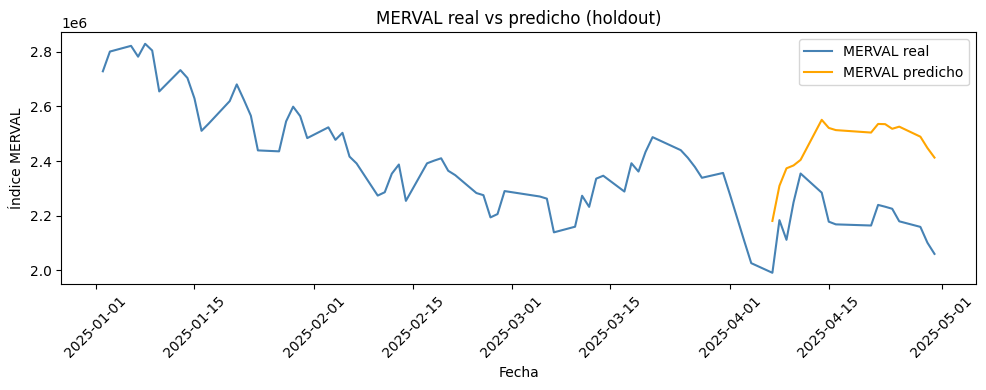

In [11]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df.index.to_timestamp(), df["merval"], label="MERVAL real", color="steelblue")
ax.plot(df.index.to_timestamp(), df["pred_merval"], label="MERVAL predicho", color="orange")

ax.set_title("MERVAL real vs predicho (holdout)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


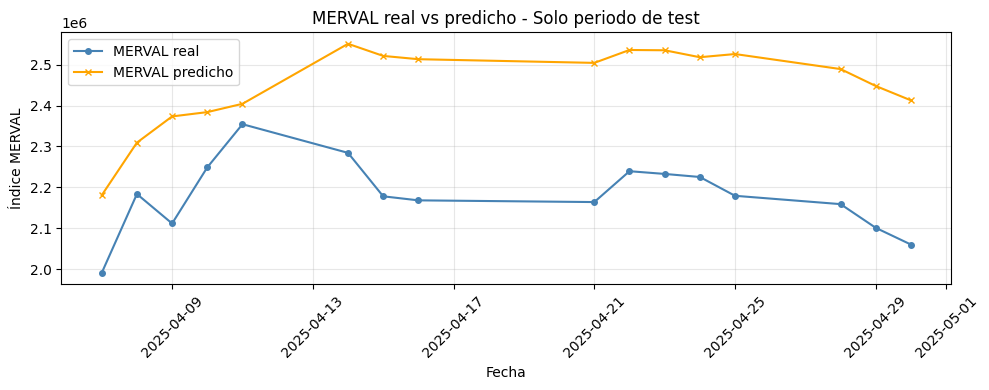

In [12]:
# Gráfico detallado solo para el periodo de test
df_test = df.loc[y_test.index]

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df_test.index.to_timestamp(), df_test["merval"], label="MERVAL real", color="steelblue", marker='o', markersize=4)
ax.plot(df_test.index.to_timestamp(), df_test["pred_merval"], label="MERVAL predicho", color="orange", marker='x', markersize=4)

ax.set_title("MERVAL real vs predicho - Solo periodo de test")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3. Análisis de residuales

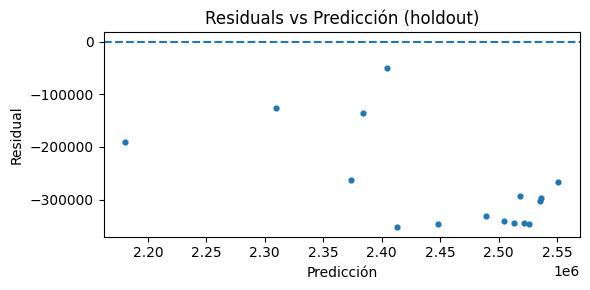

In [13]:
res = y_test - y_pred
plt.figure(figsize=(6,3))
plt.scatter(y_pred, res, s=12)
plt.axhline(0, ls="--")
plt.xlabel("Predicción")
plt.ylabel("Residual")
plt.title("Residuals vs Predicción (holdout)")
plt.tight_layout(); plt.show()


### 5.4. Importancia de variables

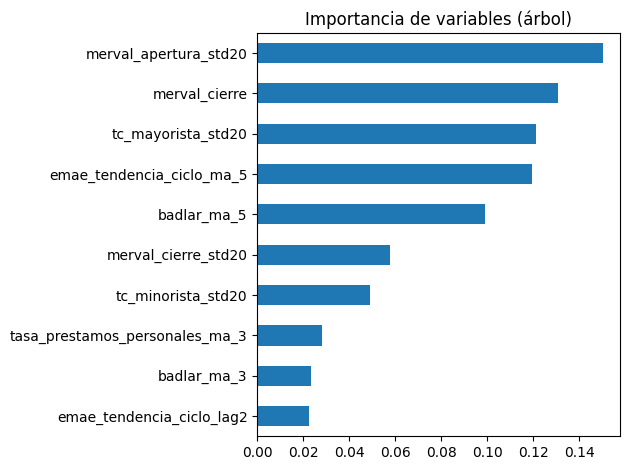

In [14]:
# Importancia de las variables

imp = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)
imp.tail(10).plot(kind="barh", title="Importancia de variables (árbol)")
plt.tight_layout(); plt.show()


## 6. Conclusiones

### Resultados principales

- **RMSE en test**: 285,651.09 - Error significativamente alto que refleja la dificultad del modelo para generalizar con datos limitados.

- **R² en test**: -10.21 - El modelo tiene un desempeño considerablemente peor que un modelo baseline que simplemente predice la media. Un R² negativo indica que las predicciones están sistemáticamente alejadas de los valores reales.

- **Error relativo**: 13.10% - Las predicciones se desvían en promedio más del 13% del valor real del MERVAL, lo cual es inaceptable para aplicaciones prácticas.

### Optimización de hiperparámetros

- Se utilizó **RandomizedSearchCV** con 60 iteraciones y validación cruzada temporal (TimeSeriesSplit con 3 folds).
- **CV RMSE**: 133,971.76 - Error promedio en validación cruzada, significativamente mejor que en test.
- Los mejores parámetros encontrados:
  - `n_estimators=237`: conjunto moderado de árboles
  - `max_depth=15`: árboles profundos (similar al modelo original)
  - `max_features=0.73`: ~44 features consideradas en cada split
  - `min_samples_split=5` y `min_samples_leaf=2`: regularización mínima

### Análisis del problema: Dataset reducido

**El dataset fue filtrado de 515 observaciones a solo 79 (63 train, 16 test)**, lo que representa una **reducción del 85%** en los datos de entrenamiento. Este cambio drástico tuvo consecuencias severas:

1. **Discrepancia CV vs Test extrema**: El RMSE de validación cruzada (133,972) es aproximadamente la mitad del RMSE de test (285,651), indicando que:
   - El modelo sufre de **alta varianza** debido a pocos datos
   - Las predicciones son extremadamente sensibles a qué datos están en train vs test
   - El periodo de test contiene patrones que no fueron capturados en los 63 días de entrenamiento

2. **Insuficiencia de datos**: Con 60 features y solo 63 observaciones, la ratio features/observaciones es ~0.95, muy cercana a 1, lo que dificulta enormemente el aprendizaje de patrones robustos.

3. **Imposibilidad de regularización efectiva**: Intentos de simplificar el modelo (menos profundidad, menos features) empeoraron aún más los resultados, sugiriendo que el problema fundamental es la escasez de datos, no el overfitting.

### Comparación con modelo original (dataset completo)

| Métrica | Dataset completo (515 obs) | Dataset reducido (79 obs) | Cambio |
|---------|---------------------------|--------------------------|--------|
| Train size | 412 | 63 | -85% |
| Test RMSE | 106,839 | 285,651 | +167% |
| Test R² | 0.32 | -10.21 | -3,266% |
| Error relativo | 4.84% | 13.10% | +171% |

La reducción del dataset causó una **degradación catastrófica del modelo**, haciendo que sea prácticamente inútil para predicciones.

### Limitaciones fundamentales

1. **Datos insuficientes para modelado supervisado**: 63 observaciones no son suficientes para entrenar un modelo de machine learning con 60 features que capture patrones complejos en series temporales financieras.

2. **Imposibilidad de capturar variabilidad**: El periodo de enero-abril 2025 puede no contener suficiente variabilidad en las condiciones de mercado para que el modelo aprenda patrones generalizables.

3. **Random Forest no es apropiado**: Este tipo de modelo requiere cantidades sustanciales de datos para funcionar correctamente. Con tan pocos datos, el ensemble no puede reducir efectivamente la varianza.

### Recomendaciones

Dado el fracaso del modelo con datos reducidos, se sugiere:

1. **Usar el dataset completo**: Si el objetivo es predicción, no hay justificación para limitar los datos a 4 meses.

2. **Modelos más simples**: Con tan pocos datos, considerar:
   - Modelos lineales (Ridge, Lasso) con regularización fuerte
   - ARIMA u otros modelos de series temporales que requieren menos observaciones
   - Promedio móvil simple o métodos heurísticos

3. **Feature engineering agresivo**: Reducir drásticamente el número de features (de 60 a 5-10) mediante selección basada en conocimiento del dominio.

4. **Transfer learning**: Entrenar con el dataset completo y fine-tunear con los últimos meses.

5. **Aceptar limitaciones**: Con 63 observaciones, es poco realista esperar predicciones confiables de un fenómeno tan complejo y volátil como el MERVAL.

**Conclusión final**: El modelo Random Forest no es viable con el dataset reducido. La pérdida de performance no es "pequeña" sino catastrófica, haciendo el modelo inutilizable para cualquier aplicación práctica.